# Classification from Scratch (NumPy only) — Response

**Role:** primary deliverable. Pure-NumPy MLP — no torch/tensorflow. `sklearn` is used ONLY for split/scaler/metrics, never for the model.

**Parity promise:** same data, same 18 features (22 dims), same architecture `Linear(22→32)→ReLU→Linear(32→1)`, same He init family, same Adam(1e-3) hyperparams, same 80/20 stratified split + scaler, same seed 42 as `classification_pytorch.ipynb` (the oracle). The oracle's curves/metrics are the expected values — see final parity section.

Pipeline: Load Data → Dataset Class (NumPy) → Batches → Model Class → Training Loop (hand backprop) → Inference Loop. Weights saved to `./weights/classification_scratch.npz`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)
os.makedirs("weights", exist_ok=True)

# ---- 1. LOAD DATA (identical cleaning to oracle) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
print("cleaned:", df.shape, "| Response rate:", round(df["Response"].mean(), 4))

CLF_NUMERIC = [
    "AcceptedCmp5", "AcceptedCmp3", "MntWines", "MntMeatProducts",
    "NumCatalogPurchases", "Recency", "Customer_Tenure_Days", "MntGoldProds",
    "Income", "MntFruits",
    "AcceptedCmp1", "AcceptedCmp2", "NumWebPurchases", "MntSweetProducts",
    "MntFishProducts", "NumStorePurchases", "Age",
]
X_num = df[CLF_NUMERIC].copy()
X_cat = pd.get_dummies(df[["Marital_Status"]], dtype=float)
X_full = pd.concat([X_num, X_cat], axis=1)
FEATURE_COLS = list(X_full.columns)
y_full = df["Response"].astype(float).values
print(f"features: {len(CLF_NUMERIC)} numeric + {X_cat.shape[1]} dummies = {len(FEATURE_COLS)} dims")

cleaned: (2237, 28) | Response rate: 0.1493
features: 17 numeric + 5 dummies = 22 dims


## 2–3. Dataset Class + batches (NumPy stand-in for DataLoader)

In [2]:
class NumpyDataset:
    """Mirrors torch Dataset API: len/getitem over float64 NumPy arrays."""
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def batch_generator(ds, batch_size=64, shuffle=True, rng=None):
    idx = np.arange(len(ds))
    if shuffle:
        idx = rng.permutation(idx)
    for s in range(0, len(ds), batch_size):
        b = idx[s:s + batch_size]
        yield ds.X[b], ds.y[b]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full.values, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
inc_idx = FEATURE_COLS.index("Income")
train_median = np.nanmedian(X_temp[:, inc_idx])
for arr in (X_temp, X_test):
    arr[:, inc_idx] = np.where(np.isnan(arr[:, inc_idx]), train_median, arr[:, inc_idx])
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
print(f"train {Xtr.shape} test {Xte.shape} | test pos rate {y_test.mean():.3f} | median fill {train_median:.0f}")
train_ds, test_ds = NumpyDataset(Xtr, y_temp), NumpyDataset(Xte, y_test)
print(f"dataset lens: {len(train_ds)} / {len(test_ds)}")

pos = (y_temp == 1).sum(); neg = (y_temp == 0).sum()
POS_W = neg / pos
print(f"pos_weight (neg/pos): {POS_W:.3f}")

train (1789, 22) test (448, 22) | test pos rate 0.150 | median fill 51533
dataset lens: 1789 / 448
pos_weight (neg/pos): 5.700


## 4. Model Class — `Linear(22→32)→ReLU→Linear(32→1)`, He init (same family/scale as oracle)

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

class ScratchMLP:
    def __init__(self, in_dim=22, h=32, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((in_dim, h)) * np.sqrt(2.0 / in_dim)  # He
        self.b1 = np.zeros(h)
        self.W2 = rng.standard_normal((h, 1)) * np.sqrt(2.0 / h)
        self.b2 = np.zeros(1)
        # Adam states (identical hypers to oracle)
        self.mW1 = np.zeros_like(self.W1); self.vW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1); self.vb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2); self.vW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2); self.vb2 = np.zeros_like(self.b2)
        self.t = 0
    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = np.maximum(0, Z1)  # ReLU
        logits = A1 @ self.W2 + self.b2
        return Z1, A1, logits
    def predict_proba(self, X):
        return sigmoid(self.forward(X)[2]).ravel()
    def adam_step(self, grads, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for name in ("W1", "b1", "W2", "b2"):
            g = grads[name]
            m = getattr(self, "m" + name); v = getattr(self, "v" + name)
            m[:] = b1 * m + (1 - b1) * g
            v[:] = b2 * v + (1 - b2) * g * g
            mhat = m / (1 - b1 ** self.t); vhat = v / (1 - b2 ** self.t)
            getattr(self, name).__isub__(lr * mhat / (np.sqrt(vhat) + eps))

model = ScratchMLP(in_dim=len(FEATURE_COLS), h=32, seed=SEED)
n_params = model.W1.size + model.b1.size + model.W2.size + model.b2.size
print(f"params: {n_params} (expect 769)")
print(f"W1 {model.W1.shape} b1 {model.b1.shape} W2 {model.W2.shape} b2 {model.b2.shape}")

params: 769 (expect 769)
W1 (22, 32) b1 (32,) W2 (32, 1) b2 (1,)


## 5. Training Loop — hand forward + weighted-BCE backprop + Adam (50 epochs)

epoch 01 | train_loss 1.5416 | val_loss 0.5953 | val_acc 0.6652 | val_f1 0.2574
epoch 10 | train_loss 0.7534 | val_loss 0.4697 | val_acc 0.7679 | val_f1 0.4694
epoch 20 | train_loss 0.6512 | val_loss 0.4434 | val_acc 0.7835 | val_f1 0.4868
epoch 30 | train_loss 0.6115 | val_loss 0.4383 | val_acc 0.7857 | val_f1 0.4839


epoch 40 | train_loss 0.5850 | val_loss 0.4347 | val_acc 0.7835 | val_f1 0.4813


epoch 50 | train_loss 0.5646 | val_loss 0.4357 | val_acc 0.7879 | val_f1 0.4920
saved: weights/classification_scratch.npz + scratch_history.csv


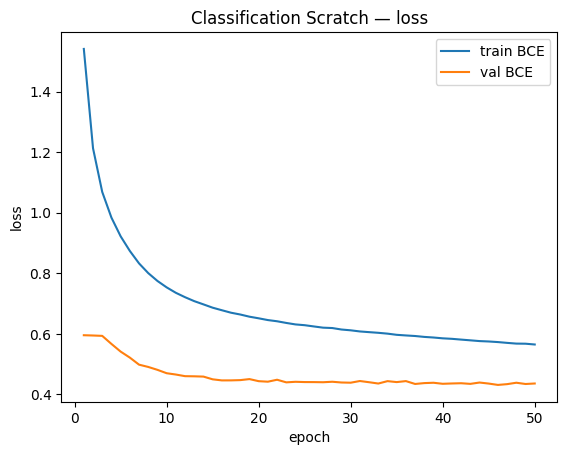

In [4]:
EPOCHS, BATCH = 50, 64
EPS = 1e-12
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
rng = np.random.default_rng(SEED)

def bce_pw(proba, y, pw):
    p = np.clip(proba, EPS, 1 - EPS)
    return float(-(pw * y * np.log(p) + (1 - y) * np.log(1 - p)).mean())

def evaluate(m):
    prob = m.predict_proba(test_ds.X)
    pred = (prob >= 0.5).astype(int)
    return (bce_pw(prob.reshape(-1, 1), test_ds.y, 1.0),
            accuracy_score(y_test, pred), f1_score(y_test, pred))

for epoch in range(1, EPOCHS + 1):
    tot, n = 0.0, 0
    for xb, yb in batch_generator(train_ds, BATCH, True, rng):
        B = len(xb)
        Z1, A1, logits = model.forward(xb)
        prob = sigmoid(logits)
        tot += bce_pw(prob, yb, POS_W) * B; n += B
        # --- backward (weighted BCE + ReLU), mean reduction ---
        dlogit = (prob + prob * yb * (POS_W - 1) - POS_W * yb) / B
        dW2 = A1.T @ dlogit; db2 = dlogit.sum(axis=0)
        dA1 = dlogit @ model.W2.T
        dZ1 = dA1 * (Z1 > 0)
        dW1 = xb.T @ dZ1; db1 = dZ1.sum(axis=0)
        model.adam_step({"W1": dW1, "b1": db1, "W2": dW2, "b2": db2})
    vl, va, vf = evaluate(model)
    history["epoch"].append(epoch)
    history["train_loss"].append(tot / n)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | train_loss {tot/n:.4f} | val_loss {vl:.4f} | val_acc {va:.4f} | val_f1 {vf:.4f}")

np.savez("weights/classification_scratch.npz", W1=model.W1, b1=model.b1, W2=model.W2, b2=model.b2,
         mean=scaler.mean_, scale=scaler.scale_, columns=np.array(FEATURE_COLS),
         train_median=np.array([train_median]))
pd.DataFrame(history).to_csv("weights/classification_scratch_history.csv", index=False)
print("saved: weights/classification_scratch.npz + scratch_history.csv")

plt.figure(); plt.plot(history["epoch"], history["train_loss"], label="train BCE")
plt.plot(history["epoch"], history["val_loss"], label="val BCE")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Classification Scratch — loss"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights/classification_scratch.npz`

In [5]:
z = np.load("weights/classification_scratch.npz")
fresh = ScratchMLP(in_dim=len(FEATURE_COLS), h=32, seed=0)
fresh.W1, fresh.b1, fresh.W2, fresh.b2 = z["W1"], z["b1"], z["W2"], z["b2"]
prob = fresh.predict_proba(test_ds.X)
pred = (prob >= 0.5).astype(int)
test_bce = bce_pw(prob.reshape(-1, 1), test_ds.y, 1.0)  # unweighted reporting loss
metrics = {
    "test_loss_BCE": round(float(test_bce), 4),
    "accuracy": round(float(accuracy_score(y_test, pred)), 4),
    "precision": round(float(precision_score(y_test, pred, zero_division=0)), 4),
    "recall": round(float(recall_score(y_test, pred, zero_division=0)), 4),
    "f1": round(float(f1_score(y_test, pred, zero_division=0)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, prob)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights/classification_scratch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  prob={prob[i]:.3f} pred={pred[i]} true={int(y_test[i])}")

{
  "test_loss_BCE": 0.4357,
  "accuracy": 0.7879,
  "precision": 0.3833,
  "recall": 0.6866,
  "f1": 0.492,
  "roc_auc": 0.8617,
  "n_test": 448,
  "seed": 42
}
  prob=0.066 pred=0 true=0
  prob=0.000 pred=0 true=0
  prob=0.028 pred=0 true=0
  prob=0.268 pred=0 true=0
  prob=0.051 pred=0 true=0


## 7. Parity check — scratch vs PyTorch oracle (oracle must run first)

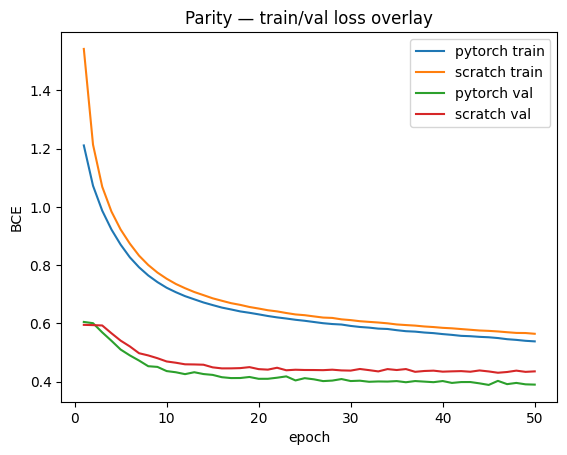

metric          pytorch  scratch    absΔ
test_loss_BCE    0.3903   0.4357  0.0454
accuracy         0.8036   0.7879  0.0157
precision        0.4087   0.3833  0.0254
recall           0.7015   0.6866  0.0149
f1               0.5165    0.492  0.0245
roc_auc          0.8725   0.8617  0.0108

PARITY: PASS (tolerances: lossΔ<0.05, F1Δ<0.05; init RNGs differ by library, so exact match is not expected)


In [6]:
import os as _os
assert _os.path.exists("weights/classification_pytorch_history.csv"), "run classification_pytorch.ipynb first"
ph = pd.read_csv("weights/classification_pytorch_history.csv")
sh = pd.read_csv("weights/classification_scratch_history.csv")
plt.figure(); plt.plot(ph["epoch"], ph["train_loss"], label="pytorch train")
plt.plot(sh["epoch"], sh["train_loss"], label="scratch train")
plt.plot(ph["epoch"], ph["val_loss"], label="pytorch val")
plt.plot(sh["epoch"], sh["val_loss"], label="scratch val")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.legend()
plt.title("Parity — train/val loss overlay"); plt.show()
pm = json.load(open("weights/classification_pytorch_test_metrics.json"))
sm = json.load(open("weights/classification_scratch_test_metrics.json"))
rows = []
for k in ("test_loss_BCE", "accuracy", "precision", "recall", "f1", "roc_auc"):
    rows.append((k, pm[k], sm[k], round(abs(sm[k] - pm[k]), 4)))
print(f"{'metric':<14}{'pytorch':>9}{'scratch':>9}{'absΔ':>8}")
for k, p, s, d in rows:
    print(f"{k:<14}{p:>9}{s:>9}{d:>8}")
loss_ok = abs(sm["test_loss_BCE"] - pm["test_loss_BCE"]) < 0.05
f1_ok = abs(sm["f1"] - pm["f1"]) < 0.05
print("\nPARITY:", "PASS" if (loss_ok and f1_ok) else "FAIL",
      "(tolerances: lossΔ<0.05, F1Δ<0.05; init RNGs differ by library, so exact match is not expected)")